# Projeto G1 — Análise de Redes Sociais e Engajamento Digital
## 1. Introdução
Investigar padrões descritivos de engajamento de 2015 a 2024. Base simulada fornecida pelo professor.
## 2. Contextualização
Indicadores de marketing digital ajudam a comparar conteúdos e públicos. Os resultados desta simulação não são recomendações para plataformas reais.
## 3. Base de dados
Cada linha representa um registro de publicação, com plataforma, perfil, categoria, formato, métricas e horário. Não existe identificador de campanha. Seguidores podem repetir entre linhas.

In [1]:
from pathlib import Path
import sys
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
raiz = Path.cwd()
if not (raiz / 'analise.py').exists():
    raiz = raiz.parent
sys.path.insert(0, str(raiz))
from analise import carregar, indicadores
bruto = pd.read_csv(raiz / 'dados/simulacao_redes_sociais_brasil.csv')
print(bruto.shape)
print(bruto.head().to_string(index=False))

(4440, 15)
 ano  mes       data plataforma      perfil      categoria tipo_conteudo  seguidores  curtidas  comentarios  compartilhamentos  visualizacoes  alcance  taxa_engajamento horario_publicacao
2015    1 2015-01-01   LinkedIn EducaOnline Entretenimento         Vídeo      608562     60519         4204               8462          46688   601986              3.31              08:00
2015    1 2015-01-01     TikTok     GamesBR     Tecnologia        Imagem      733755     77926          199               7096        1635721  1798994              7.68              08:00
2015    1 2015-01-01   LinkedIn     GamesBR       Educação       Stories      986048     48692         4437               2047        1799255  2354880              4.79              18:00
2015    1 2015-01-01    YouTube    ModaHoje          Games        Imagem      814782     49169         3738               1740         195735  2072736              3.26              12:00
2015    1 2015-01-01   Facebook  TechBrasil     T

## 4. Limpeza e preparação
Verificar ausências, duplicatas, datas e métricas negativas. Nenhuma alteração artificial é feita para melhorar resultados.

In [2]:
print('Ausências:', bruto.isna().sum().sum())
print('Duplicatas:', bruto.duplicated().sum())
df = carregar()
print('Datas:', df.data.min(), df.data.max())
print('Ano e mês originais consistentes:', bool(((bruto.ano == df.ano) & (bruto.mes == df.mes)).all()))

Ausências: 0
Duplicatas: 0
Datas: 2015-01-01 00:00:00 2024-12-01 00:00:00
Ano e mês originais consistentes: True


## 5. Engenharia de atributos
Criamos hora, período mensal, total de interações e taxa calculada por alcance. A taxa informada na base tem definição não documentada; por isso não é substituída pela taxa calculada.

In [3]:
print(df[['hora','periodo','interacoes','taxa_engajamento','engajamento_por_alcance']].head().to_string(index=False))

 hora periodo  interacoes  taxa_engajamento  engajamento_por_alcance
    8 2015-01       73185              3.31                12.157259
    8 2015-01       85221              7.68                 4.737148
   18 2015-01       55176              4.79                 2.343049
   12 2015-01       54647              3.26                 2.636467
   21 2015-01       10094              3.48                 0.410742


## 6. Análise exploratória
Distribuições e tamanhos dos grupos ajudam a interpretar diferenças médias.

In [4]:
print(df.describe().round(2).to_string())
print(df.groupby('plataforma').size())

           ano      mes                 data  seguidores  curtidas  comentarios  compartilhamentos  visualizacoes     alcance  taxa_engajamento     hora  interacoes  engajamento_por_alcance
count  4440.00  4440.00                 4440     4440.00   4440.00      4440.00            4440.00        4440.00     4440.00           4440.00  4440.00     4440.00                  4440.00
mean   2019.50     6.50  2019-12-16 10:48:00   500083.76  40093.57      2489.47            4992.84     1007836.40  1262404.42              6.24    14.79    47575.88                    13.81
min    2015.00     1.00  2015-01-01 00:00:00     1345.00    170.00        10.00              10.00        2554.00     1853.00              0.50     8.00     2454.00                     0.11
25%    2017.00     3.75  2017-06-23 12:00:00   253730.00  20187.00      1230.50            2516.75      518828.25   640140.25              3.32     8.00    27633.00                     2.15
50%    2019.50     6.50  2019-12-16 12:00:00   502

## 7. KPIs
Seguidores somados são uma soma de registros, não pessoas únicas. O melhor formato usa alcance médio; o melhor horário e a melhor plataforma usam a média simples da taxa informada.

In [5]:
k = indicadores(df)
for nome, valor in k.items():
    print(nome, ':', valor)

publicacoes : 4440
seguidores_somados : 2220371880
engajamento_medio : 6.235231981981982
visualizacoes : 4474793612
plataforma : LinkedIn
conteudo : Live
horario : 21:00


## 8. Visualizações
Gráficos de linha, barras, mapa de calor e dispersão com Matplotlib e Seaborn. O dashboard complementa com Plotly.

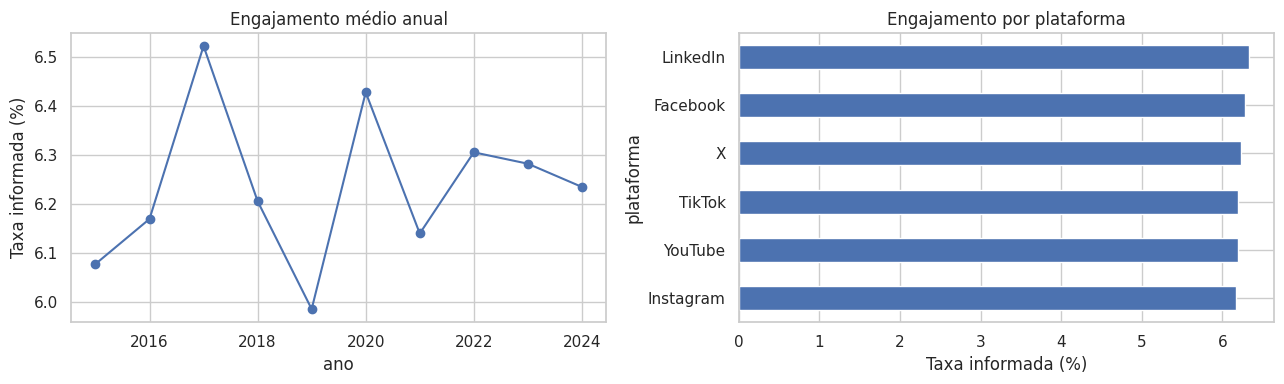

In [6]:
sns.set_theme(style='whitegrid')
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
df.groupby('ano').taxa_engajamento.mean().plot(ax=axes[0], marker='o', title='Engajamento médio anual')
axes[0].set_ylabel('Taxa informada (%)')
df.groupby('plataforma').taxa_engajamento.mean().sort_values().plot.barh(ax=axes[1], title='Engajamento por plataforma')
axes[1].set_xlabel('Taxa informada (%)')
fig.tight_layout()

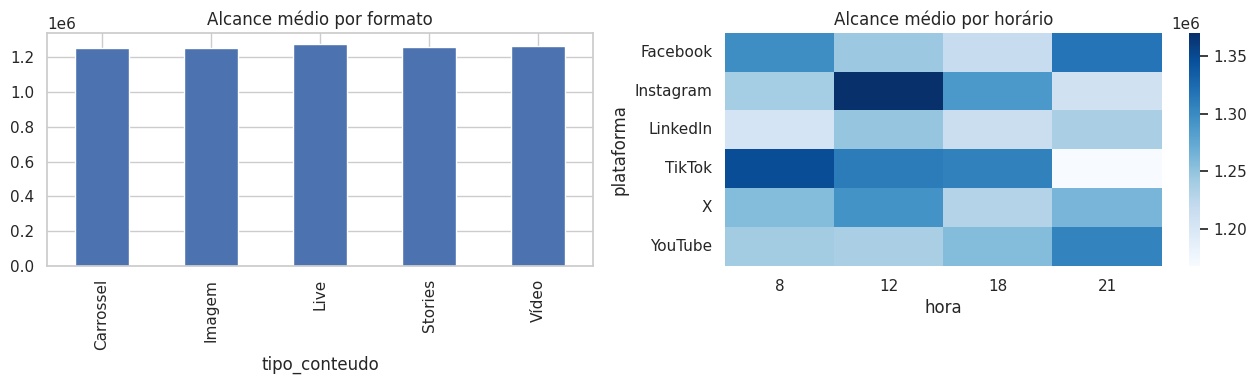

In [7]:
fig, axes = plt.subplots(1,2,figsize=(13,4))
df.groupby('tipo_conteudo').alcance.mean().plot.bar(ax=axes[0], title='Alcance médio por formato')
sns.heatmap(df.pivot_table(index='plataforma',columns='hora',values='alcance',aggfunc='mean'),ax=axes[1],cmap='Blues')
axes[1].set_title('Alcance médio por horário')
fig.tight_layout()

seguidores          -0.014
curtidas            -0.000
comentarios         -0.007
compartilhamentos   -0.010
visualizacoes        0.011
alcance              0.009
taxa_engajamento     1.000


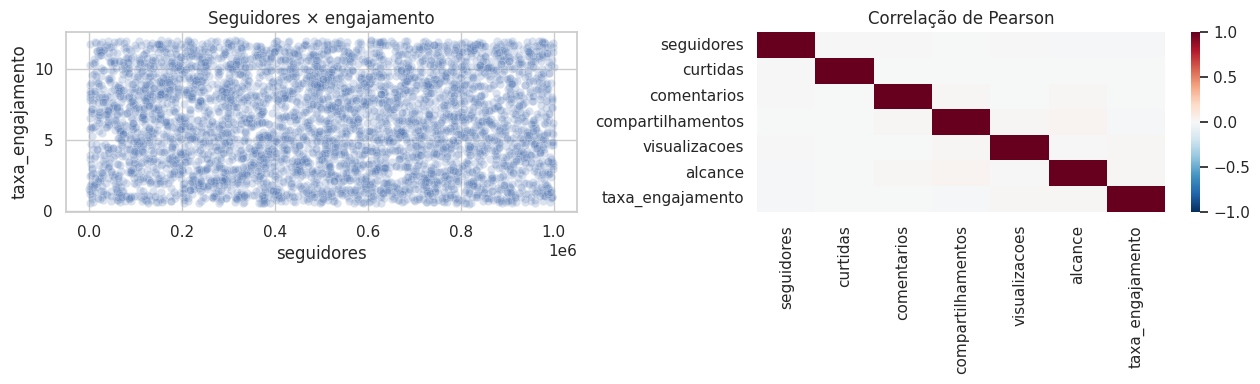

In [8]:
fig,axes=plt.subplots(1,2,figsize=(13,4))
sns.scatterplot(data=df,x='seguidores',y='taxa_engajamento',alpha=.2,ax=axes[0])
axes[0].set_title('Seguidores × engajamento')
cols=['seguidores','curtidas','comentarios','compartilhamentos','visualizacoes','alcance','taxa_engajamento']
sns.heatmap(df[cols].corr(),vmin=-1,vmax=1,cmap='RdBu_r',ax=axes[1])
axes[1].set_title('Correlação de Pearson')
fig.tight_layout()
print(df[cols].corr()['taxa_engajamento'].round(3).to_string())

## 9. Análises complementares
Ranking por conta; evolução dos seguidores medianos por conta/ano; frequência por conta/mês e alcance médio; alcance elevado definido pelo percentil 95.

In [9]:
print(df.groupby(['plataforma','perfil']).taxa_engajamento.mean().sort_values(ascending=False).head(10))
evolucao = df.groupby(['ano','plataforma','perfil']).seguidores.median()
print(evolucao.head(12))
frequencia = df.groupby(['periodo','plataforma','perfil']).agg(postagens=('data','size'),alcance_medio=('alcance','mean'))
print('Correlação frequência × alcance médio:', frequencia.postagens.corr(frequencia.alcance_medio))
limite = df.alcance.quantile(.95)
print('Percentil 95 do alcance:', limite)
print(df[df.alcance >= limite].sort_values('alcance',ascending=False).head(10).to_string(index=False))

plataforma  perfil     
X           TechBrasil     6.800117
Facebook    EducaOnline    6.646509
LinkedIn    ModaHoje       6.519405
YouTube     ModaHoje       6.517062
TikTok      ModaHoje       6.488043
LinkedIn    GamesBR        6.354211
Facebook    TechBrasil     6.347045
TikTok      EducaOnline    6.331607
Instagram   ModaHoje       6.319821
LinkedIn    EducaOnline    6.293757
Name: taxa_engajamento, dtype: float64
ano   plataforma  perfil     
2015  Facebook    EducaOnline    498600.0
                  GamesBR        492123.5
                  ModaHoje       493389.0
                  TechBrasil     540803.0
      Instagram   EducaOnline    529659.5
                  GamesBR        333291.0
                  ModaHoje       208750.0
                  TechBrasil     573254.5
      LinkedIn    EducaOnline    394289.0
                  GamesBR        394835.0
                  ModaHoje       501893.0
                  TechBrasil     395118.0
Name: seguidores, dtype: float64
Correlação

## 10. Interpretação
LinkedIn apresenta média de 6,32%, enquanto Instagram apresenta 6,17%: diferença aproximada de 0,15 ponto percentual, sem teste de significância. Lives lideram o alcance médio e 21h lidera o engajamento médio informado. A soma de visualizações é acumulada e não representa público único.

A evolução dos seguidores é descritiva: valores simulados e repetidos não comprovam aquisição ou perda real de seguidores. Correlações não demonstram causalidade. O corte de alcance identifica registros elevados dentro da amostra, sem comprovar viralidade. Campanhas não podem ser analisadas sem uma coluna que as identifique.
## 11. Conclusão
O projeto permite explorar recortes e comparar métricas com transparência. A escolha de estratégias reais exigiria dados observados, definição das métricas, acompanhamento consistente de cada conta e testes adicionais.
## 12. Funcionalidades avançadas
O aplicativo implementa navegação multipágina e persistência em SQLite via SQLAlchemy, incluindo consulta SQL para conferir os registros gravados.